<a href="https://colab.research.google.com/github/raflyalvish-id/customer-churn-analysis/blob/main/customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **CUSTOMER CHURN ANALYSIS**

---




# **Data Description**

```
ABOUT DATA
----------
A fictional telco company that provided home phone and Internet services to 7043 customers in California in Q3.

COLUMNS EXPLANATION
-------------------
CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Country: The country of the customer’s primary residence.

State: The state of the customer’s primary residence.

City: The city of the customer’s primary residence.

Zip Code: The zip code of the customer’s primary residence.

Lat Long: The combined latitude and longitude of the customer’s primary residence.

Latitude: The latitude of the customer’s primary residence.

Longitude: The longitude of the customer’s primary residence.

Gender: The customer’s gender: Male, Female

Senior Citizen: Indicates if the customer is 65 or older: Yes, No

Partner: Indicate if the customer has a partner: Yes, No

Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

Tenure Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No

Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

Device Protection: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No

Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.
```

# **Set Up Environment**

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

In [35]:
# prepare data
df_churn = pd.read_csv('/Telco_customer_churn.csv')




# **Cleaning Data**

In [36]:
# Cek Duplikat
len(df_churn)

7043

In [37]:
len(df_churn.drop_duplicates())

# tidak ditemukan duplikat

7043

In [38]:
# Cek Missing Value
df_churn.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [39]:
df_churn['Total Charges'] = pd.to_numeric(df_churn['Total Charges'], errors='coerce')


In [40]:
df_churn['Total Charges'].isna().sum()

np.int64(11)

In [41]:
df_churn = df_churn.dropna(subset=['Total Charges'])

Kolom total changes masih bertipe object lalu saya ubah ke float64 agar dapat detect data yang kosong, lalu karena jumlahnya sedikit, saya memutuskan untuk drop

In [42]:
df_churn.isna().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [43]:
for column in df_churn.columns:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= CustomerID =================


,count
CustomerID,
3186-AJIEK,1
3668-QPYBK,1
9237-HQITU,1
9305-CDSKC,1
7892-POOKP,1
...,...
5380-WJKOV,1
6047-YHPVI,1
8773-HHUOZ,1



============= Count =================


,count
Count,
1,7032



============= Country =================


...

,count
Churn Score,
80,151
71,148
77,145
67,143
76,141
...,...
88,33
9,3
8,2



============= CLTV =================


,count
CLTV,
5546,8
4741,7
4745,7
4369,7
5092,7
...,...
6393,1
4543,1
6079,1



============= Churn Reason =================


,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


ditemukan data berisi "No phone service" di kolom Multiple Lines, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies yang dapat diubah menjadi "No" agar sesuai. karena termasuk data ordinal, maka bisa dilakukan label encorder

In [44]:
#Lakukan normalisasi nilai terlebih dahulu
df_churn['Streaming Movies'] = df_churn['Streaming Movies'].replace({'No internet service':'No'})
df_churn['Streaming TV'] = df_churn['Streaming TV'].replace({'No internet service':'No'})
df_churn['Tech Support'] = df_churn['Tech Support'].replace({'No internet service':'No'})
df_churn['Device Protection'] = df_churn['Device Protection'].replace({'No internet service':'No'})
df_churn['Online Backup'] = df_churn['Online Backup'].replace({'No internet service':'No'})
df_churn['Online Security'] = df_churn['Online Security'].replace({'No internet service':'No'})
df_churn['Multiple Lines'] = df_churn['Multiple Lines'].replace({'No phone service':'No'})

In [45]:
#Cek ulang nilai-nilai di kolom kategorikal
for column in df_churn.columns:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= CustomerID =================


,count
CustomerID,
3186-AJIEK,1
3668-QPYBK,1
9237-HQITU,1
9305-CDSKC,1
7892-POOKP,1
...,...
5380-WJKOV,1
6047-YHPVI,1
8773-HHUOZ,1



============= Count =================


,count
Count,
1,7032



============= Country =================


...

,count
Churn Score,
80,151
71,148
77,145
67,143
76,141
...,...
88,33
9,3
8,2



============= CLTV =================


,count
CLTV,
5546,8
4741,7
4745,7
4369,7
5092,7
...,...
6393,1
4543,1
6079,1



============= Churn Reason =================


,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


In [46]:
df_churn.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [47]:
# Cek Outliers
def check_plot(df, variable):
    # fungsi mengambil dataframe dan nama kolom

    plt.figure(figsize=(16,4))

    # Histogram
    plt.subplot(1,3,1)
    sns.histplot(df[variable], bins=30, kde=True)
    plt.title(f'Histogram of {variable}')

    # QQ Plot
    plt.subplot(1,3,2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f'QQ Plot of {variable}')
    plt.ylabel('Sample Quantiles')

    # Boxplot
    plt.subplot(1,3,3)
    sns.boxplot(y=df[variable])
    plt.title(f'Boxplot of {variable}')

    plt.tight_layout()
    plt.show()

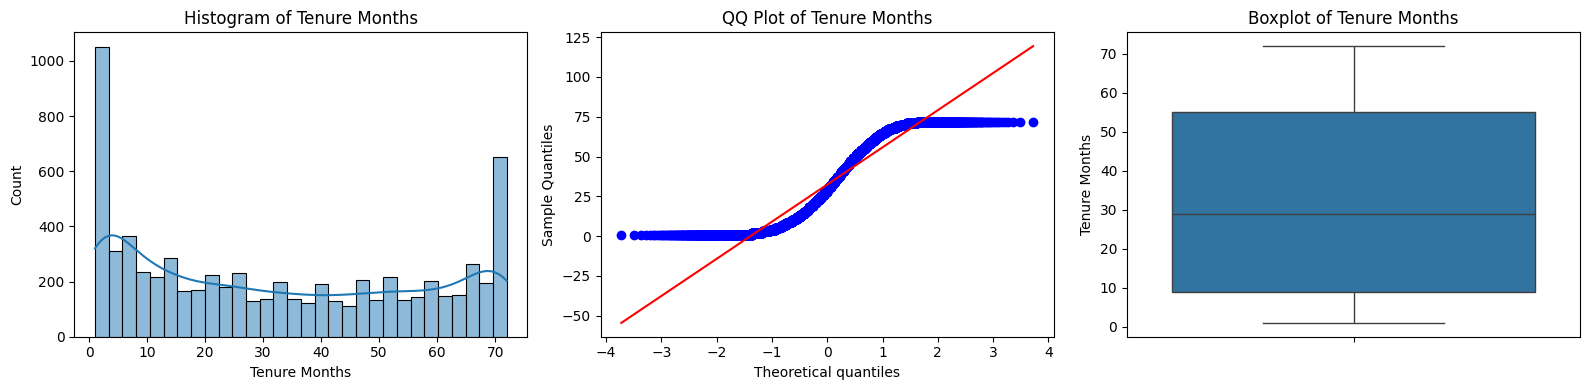

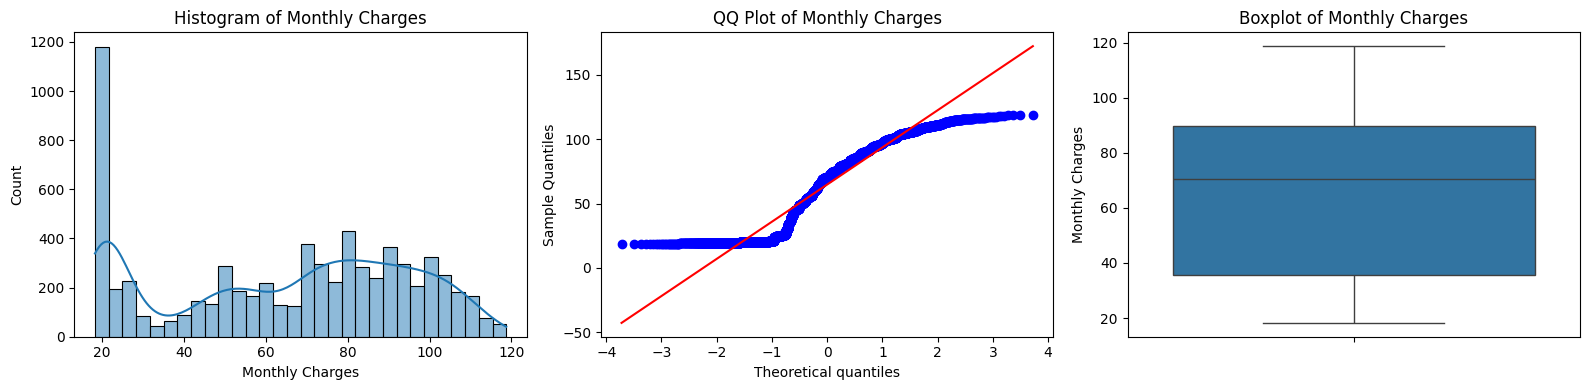

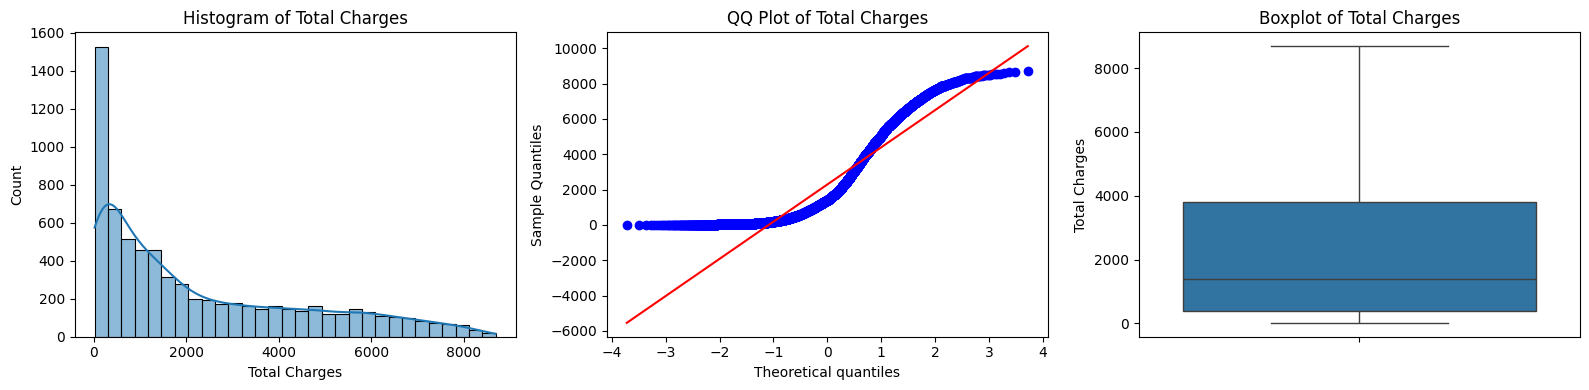

In [48]:
kolom_kolom = ['Tenure Months', 'Monthly Charges', 'Total Charges']
for kolom in kolom_kolom:
    check_plot(df_churn, kolom)

In [49]:
def find_outlier_boundary(df, variable):

    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)

    IQR = Q3 - Q1

    lower_boundary = Q1 - 1.5 * IQR
    upper_boundary = Q3 + 1.5 * IQR

    return lower_boundary, upper_boundary

In [50]:
cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
for col in cols:

    lower, upper = find_outlier_boundary(df_churn, col)

    outliers = df_churn[(df_churn[col] < lower) | (df_churn[col] > upper)]

    print(col)
    print("Jumlah outlier:", len(outliers))
    print()

Tenure Months
Jumlah outlier: 0

Monthly Charges
Jumlah outlier: 0

Total Charges
Jumlah outlier: 0



berdasarkan pengecekan outlier menggunakan metode IQR tidak ditemukan titik outlier yang ekstrim dari batas atas maupun batas bawah

# **Buat visualiasi untuk menemukan perbedaan persentase dari customer yang churn dan customer yang tidak churn**

In [51]:
# cek persentase data churn label
churn_percent = df_churn['Churn Label'].value_counts(normalize=True) * 100
churn_percent

,proportion
Churn Label,
No,73.421502
Yes,26.578498


/tmp/ipykernel_39936/4003990956.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


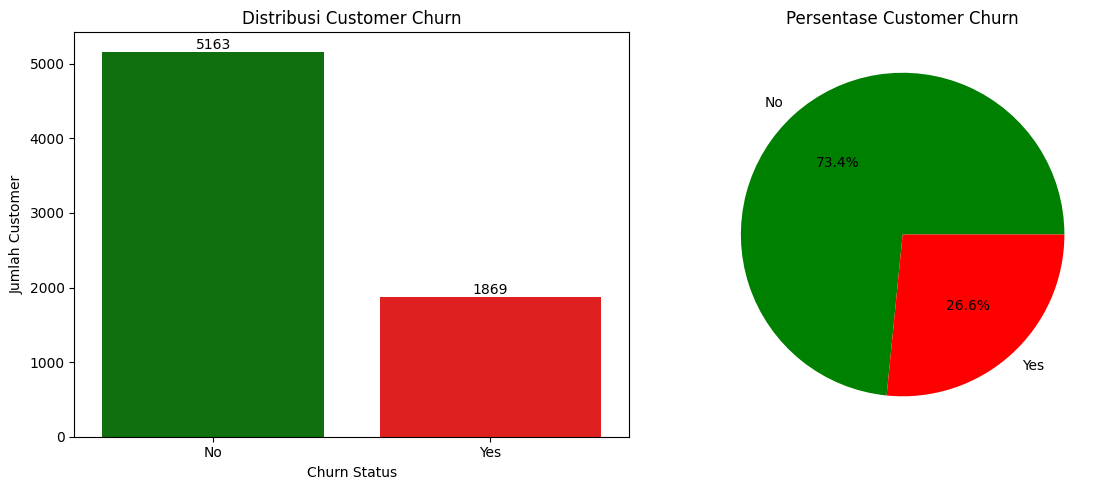

In [52]:
plt.figure(figsize=(12,5))


# Bar Chart
plt.subplot(1,2,1)

ax = sns.countplot(
    data=df_churn,
    x='Churn Label',
    order=['No','Yes'],
    palette=['green','red']
)

plt.title('Distribusi Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Jumlah Customer')

# label jumlah data di atas bar
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )


# Pie Chart
plt.subplot(1,2,2)

df_churn['Churn Label'].value_counts().reindex(['No','Yes']).plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green','red']
)

plt.title('Persentase Customer Churn')
plt.ylabel('')

plt.tight_layout()
plt.show()

**Insight:** Berdasarkan visualisasi yang ditampilkan, diketahui bahwa sekitar 26,6% pelanggan melakukan churn, sedangkan 73,4% pelanggan tetap menggunakan layanan perusahaan. Hal ini menunjukkan bahwa sebagian besar pelanggan masih bertahan menggunakan layanan yang diberikan.

Namun, persentase churn sebesar 26,6% masih tergolong cukup tinggi karena lebih dari seperempat pelanggan memutuskan untuk berhenti menggunakan layanan. Jika kondisi ini terus terjadi, perusahaan berpotensi mengalami penurunan jumlah pelanggan dan pendapatan dalam jangka panjang.

#

**Saran action:**
1.   Mengidentifikasi pelanggan yang berisiko churn. Perusahaan perlu menganalisis karakteristik pelanggan yang melakukan churn, seperti lama berlangganan, biaya bulanan, dan jenis layanan yang digunakan, agar dapat mengetahui pola pelanggan yang berpotensi berhenti menggunakan layanan.
2.   Meningkatkan kualitas layanan dan kepuasan pelanggan. Perusahaan dapat meningkatkan kualitas jaringan, kecepatan layanan, serta respons layanan pelanggan agar pelanggan merasa lebih puas dan tetap menggunakan layanan.
3.   Memberikan program loyalitas kepada pelanggan lama. Perusahaan dapat menawarkan program loyalitas seperti diskon khusus, bonus layanan tambahan, atau reward bagi pelanggan yang telah berlangganan dalam jangka waktu yang lama
4.   Memberikan penawaran atau paket layanan yang lebih menarik. Perusahaan dapat memberikan paket layanan yang lebih fleksibel dan sesuai dengan kebutuhan pelanggan agar pelanggan tidak berpindah ke layanan kompetitor.
5.   Melakukan pendekatan proaktif kepada pelanggan. Perusahaan dapat menghubungi pelanggan secara berkala untuk mengetahui tingkat kepuasan mereka serta menawarkan solusi atau promosi khusus sebelum pelanggan memutuskan untuk berhenti menggunakan layanan.




#   **Buat visualisasi untuk melihat hubungan antara `jumlah bulan yang telah dihabiskan customer` di perusahaan pada akhir kuartal dan `total tagihan customer`**




In [53]:
df_churn[['Tenure Months','Total Charges']].describe()

,Tenure Months,Total Charges
count,7032.000000,7032.000000
mean,32.421786,2283.300441
std,24.545260,2266.771362
min,1.000000,18.800000
25%,9.000000,401.450000
50%,29.000000,1397.475000
75%,55.000000,3794.737500
max,72.000000,8684.800000


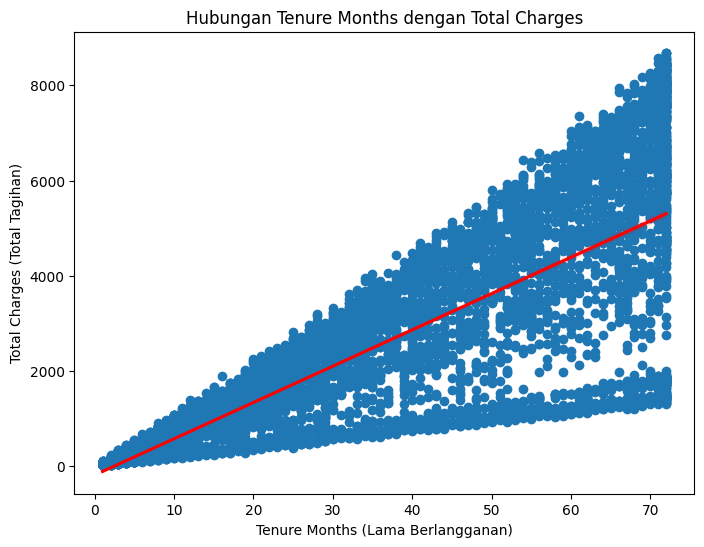

In [54]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_churn,
    x='Tenure Months',
    y='Total Charges',
    scatter_kws={'alpha':1},
    line_kws={'color':'red'}
)

plt.title('Hubungan Tenure Months dengan Total Charges')
plt.xlabel('Tenure Months (Lama Berlangganan)')
plt.ylabel('Total Charges (Total Tagihan)')

plt.show()

In [55]:
corr = df_churn['Tenure Months'].corr(df_churn['Total Charges'])
print(f"Korelasi antara Tenure Months dan Total Charges: {corr:.2f}")

Korelasi antara Tenure Months dan Total Charges: 0.83


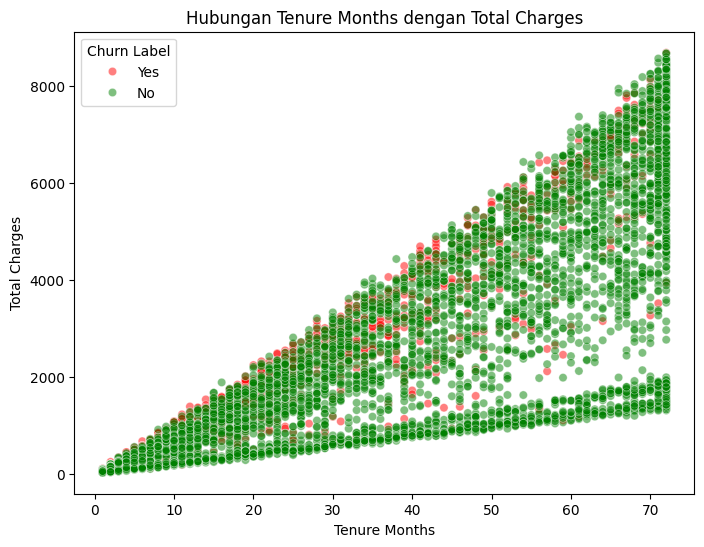

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_churn,
    x='Tenure Months',
    y='Total Charges',
    hue='Churn Label',
    palette=['red','green'],
    alpha=0.5
)

plt.title('Hubungan Tenure Months dengan Total Charges')
plt.xlabel('Tenure Months')
plt.ylabel('Total Charges')

plt.show()


**Insight:** Berdasarkan visualisasi scatter plot, terlihat adanya hubungan positif yang kuat antara Tenure Months dan Total Charges. Hal ini juga diperkuat oleh nilai korelasi sebesar 0,83, yang menunjukkan bahwa semakin lama pelanggan berlangganan dengan perusahaan, maka total tagihan yang dibayarkan pelanggan cenderung semakin meningkat. Pola sebaran data pada grafik juga menunjukkan tren yang terus meningkat seiring bertambahnya lama berlangganan pelanggan.

Berdasarkan statistik deskriptif, rata-rata lama berlangganan pelanggan adalah sekitar 32 bulan, dengan median sekitar 29 bulan, sedangkan rata-rata total tagihan pelanggan adalah sekitar 2283 dengan median sekitar 1397. Hal ini menunjukkan adanya variasi penggunaan layanan antar pelanggan. Selain itu, pada grafik juga terlihat bahwa pelanggan dengan tenure yang lebih rendah cenderung lebih banyak yang churn, sedangkan pelanggan dengan tenure yang lebih tinggi sebagian besar tetap menggunakan layanan.
#

**Saran Action:**
1.   Mempertahankan pelanggan dengan tenure tinggi. Pelanggan yang telah berlangganan lebih lama memberikan kontribusi pendapatan yang lebih besar sehingga perlu dipertahankan melalui program loyalitas.

2.   Meningkatkan retensi pelanggan baru. Pelanggan dengan tenure rendah perlu diberikan pengalaman layanan yang baik agar mereka tetap bertahan dan tidak melakukan churn di awal masa berlangganan.

3.   Menyediakan paket layanan yang sesuai dengan kebutuhan pelanggan
Perusahaan dapat menawarkan paket layanan yang fleksibel agar pelanggan merasa layanan yang diberikan sesuai dengan kebutuhan mereka.

4.   Memberikan promo atau insentif untuk meningkatkan penggunaan layanan
Penawaran paket bundling atau diskon layanan tambahan dapat meningkatkan penggunaan layanan dan total revenue pelanggan.

5.   Melakukan monitoring terhadap pelanggan dengan penggunaan layanan rendah
Pelanggan dengan tenure tinggi namun total charges rendah dapat dianalisis lebih lanjut untuk memahami pola penggunaan layanan mereka.

# **Buat visualisasi untuk melihat 5 `kota` teratas yang customernya melakukan churn dan tidak melakukan churn**


In [57]:
top_city = df_churn.groupby(['City','Churn Label']).size().reset_index(name='Total')

top_city

,City,Churn Label,Total
0,Acampo,No,1
1,Acampo,Yes,3
2,Acton,No,4
3,Adelanto,No,4
4,Adelanto,Yes,1
...,...,...,...
1945,Yucaipa,No,3
1946,Yucaipa,Yes,1
1947,Yucca Valley,No,5
1948,Zenia,No,3


In [58]:
top5_city = df_churn['City'].value_counts().head(5).index

top_city = df_churn[df_churn['City'].isin(top5_city)]

top5_city

Index(['Los Angeles', 'San Diego', 'San Jose', 'Sacramento', 'San Francisco'], dtype='object', name='City')

In [59]:
city_churn = top_city.groupby(['City','Churn Label']).size().unstack()

city_churn

Churn Label,No,Yes
City,,
Los Angeles,214,90
Sacramento,82,26
San Diego,100,50
San Francisco,73,31
San Jose,83,29


In [60]:
city_churn_percent = city_churn.div(city_churn.sum(axis=1), axis=0) * 100

city_churn_percent.round(1)

Churn Label,No,Yes
City,,
Los Angeles,70.4,29.6
Sacramento,75.9,24.1
San Diego,66.7,33.3
San Francisco,70.2,29.8
San Jose,74.1,25.9


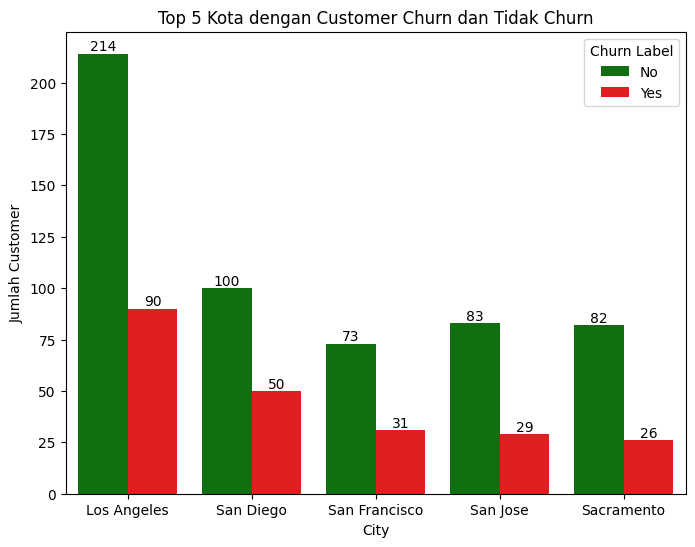

In [61]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=top_city,
    x='City',
    hue='Churn Label',
    hue_order=['No','Yes'],
    palette=['green','red']
)

plt.title('Top 5 Kota dengan Customer Churn dan Tidak Churn')
plt.xlabel('City')
plt.ylabel('Jumlah Customer')

# label jumlah di atas bar
for p in ax.patches:
    height = p.get_height()

    if height > 0:
        ax.annotate(
            int(height),
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom'
        )

plt.show()

**Insight:** Berdasarkan visualisasi lima kota dengan jumlah pelanggan terbanyak, terlihat bahwa Los Angeles memiliki jumlah pelanggan paling besar dengan total 304 pelanggan, terdiri dari 214 pelanggan tidak churn (70,4%) dan 90 pelanggan churn (29,6%). Kota lain seperti San Diego memiliki tingkat churn sekitar 33,3%, yang merupakan persentase churn tertinggi di antara lima kota tersebut. Sementara itu, San Francisco memiliki churn sekitar 29,8%, diikuti oleh San Jose sebesar 25,9% dan Sacramento sebesar 24,1%.

Kelima kota tersebut memiliki jumlah pelanggan yang tidak churn lebih tinggi dibandingkan yang churn, dengan persentase berkisar antara 66% hingga 76% pelanggan yang tetap menggunakan layanan. Namun demikian, beberapa kota seperti San Diego dan Los Angeles memiliki tingkat churn yang relatif lebih tinggi, sehingga kota-kota tersebut dapat menjadi fokus utama bagi perusahaan dalam meningkatkan strategi retensi pelanggan.

#

**Saran Action:**
1. Memfokuskan strategi retensi pada kota dengan jumlah churn terbesar
Kota seperti Los Angeles (90 churn) dan San Diego (50 churn) memiliki jumlah pelanggan yang berhenti cukup tinggi sehingga perlu menjadi prioritas dalam strategi retensi pelanggan.

2. Melakukan analisis lebih lanjut terhadap karakteristik pelanggan di kota-kota tersebut
Perusahaan dapat menganalisis faktor seperti lama berlangganan, biaya bulanan, dan jenis layanan untuk memahami penyebab pelanggan di kota-kota tersebut melakukan churn.

3. Meningkatkan kualitas layanan di kota dengan jumlah pelanggan besar
Kota dengan jumlah pelanggan tinggi seperti Los Angeles dan San Diego perlu mendapatkan perhatian khusus dalam hal kualitas layanan agar pelanggan tetap loyal.

4. Memberikan promosi atau program loyalitas pada kota dengan churn tinggi
Perusahaan dapat menawarkan diskon, paket layanan tambahan, atau promo khusus bagi pelanggan di kota dengan tingkat churn yang relatif tinggi.

5. Melakukan survei kepuasan pelanggan secara berkala
Dengan melakukan survei kepuasan pelanggan di kota-kota utama, perusahaan dapat mengetahui permasalahan yang dialami pelanggan dan mengambil tindakan yang tepat untuk meningkatkan kepuasan serta mengurangi churn.

#  **Buat visualisasi untuk melihat persebaran data dari `tenure months` untuk masing-masing `churn label`**


In [62]:
df_churn.groupby('Churn Label')['Tenure Months'].median()

,Tenure Months
Churn Label,
No,38.0
Yes,10.0


/tmp/ipykernel_39936/1573449092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


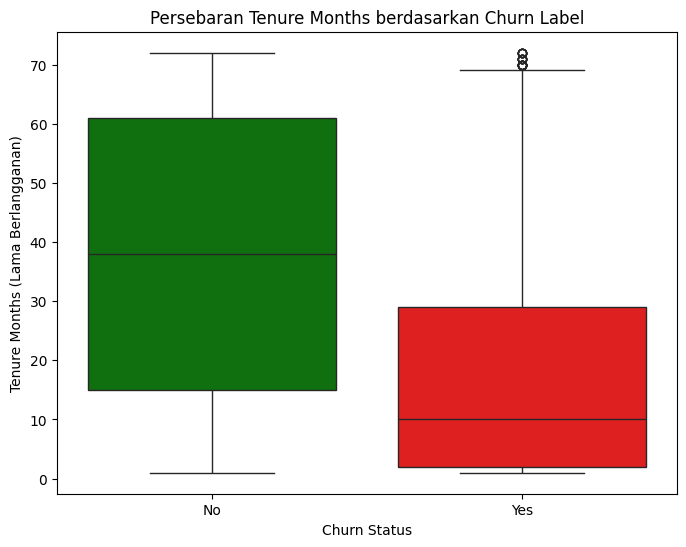

In [63]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_churn,
    x='Churn Label',
    y='Tenure Months',
    order=['No','Yes'],
    palette=['green','red']
)

plt.title('Persebaran Tenure Months berdasarkan Churn Label')
plt.xlabel('Churn Status')
plt.ylabel('Tenure Months (Lama Berlangganan)')

plt.show()

**Insight:** Berdasarkan visualisasi boxplot, terlihat bahwa pelanggan yang tidak melakukan churn (No) memiliki nilai Tenure Months yang jauh lebih tinggi dibandingkan pelanggan yang churn. Median tenure untuk pelanggan yang tidak churn berada sekitar 37–38 bulan, yang menunjukkan bahwa sebagian besar pelanggan yang bertahan telah menggunakan layanan perusahaan dalam jangka waktu yang cukup lama.

Sebaliknya, pelanggan yang melakukan churn (Yes) memiliki median tenure yang jauh lebih rendah, yaitu sekitar 10 bulan. Hal ini menunjukkan bahwa banyak pelanggan berhenti menggunakan layanan pada tahap awal masa berlangganan. Selain itu, sebagian besar pelanggan churn memiliki tenure di bawah 30 bulan, yang mengindikasikan bahwa periode awal penggunaan layanan merupakan fase yang paling rentan terhadap churn.

#

**Saran Action:**
1. Meningkatkan pengalaman pelanggan pada awal masa berlangganan
Karena banyak pelanggan churn pada tenure rendah, perusahaan perlu memastikan pengalaman awal pelanggan berjalan dengan baik.

2. Memberikan program onboarding pelanggan baru
Perusahaan dapat memberikan panduan penggunaan layanan atau promosi khusus bagi pelanggan baru agar mereka lebih memahami manfaat layanan.

3. Memberikan insentif untuk pelanggan dengan tenure rendah
Diskon atau promo khusus pada beberapa bulan pertama dapat membantu meningkatkan retensi pelanggan baru.

4. Mempertahankan pelanggan dengan tenure tinggi
Pelanggan dengan tenure yang lebih lama cenderung loyal sehingga perusahaan dapat memberikan program loyalitas atau reward.

5. Melakukan monitoring terhadap pelanggan baru
Dengan memantau aktivitas pelanggan pada bulan-bulan awal, perusahaan dapat mengidentifikasi pelanggan yang berpotensi churn dan mengambil tindakan lebih awal.